# Deep Learning Assignment 2026 — Starting Code

## Loading Dataset

You can download the dataset from
https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images

The Lung and Colon Cancer Histopathological Image Dataset (LC25000) consists of 25,000
histopathological images from 5 classes, with 5,000 images per class:

| Folder | Class |
| --- | --- |
| `colon_aca` | Colon adenocarcinoma |
| `colon_n` | Benign colonic tissue |
| `lung_aca` | Lung adenocarcinoma |
| `lung_n` | Benign lung tissue |
| `lung_scc` | Lung squamous cell carcinoma |

The cells below download the dataset, read all 25,000 images and resize them from
768 x 768 to **120 x 120**.

**Before you start:** Runtime -> Change runtime type -> **T4 GPU**. On a CPU runtime the
models in this assignment take many times longer to train.

### Step 1 — Download the dataset

`kagglehub` downloads the dataset and returns the path to it. You need a free Kaggle
account. If you are asked to authenticate, go to your Kaggle account page
(**Settings -> API -> Create New Token**), which downloads a `kaggle.json` file containing
your username and key, and enter those when prompted.

The first run downloads about 1.9 GB. Later runs reuse the cached copy.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

/Users/nightsky/miniforge3/envs/Deep_Learning_M/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/nightsky/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1


### Step 2 — Check the folder structure

Run this before the loading step. If the paths are wrong you will see it here immediately,
rather than after 25,000 error messages.

In [2]:
import os

root = os.path.join(path, "lung_colon_image_set")
for r, dirs, fnames in os.walk(root):
    depth = r.replace(path, "").count(os.sep)
    print("  " * depth + os.path.basename(r) + f"  ({len(fnames)} files)")

  lung_colon_image_set  (0 files)
    lung_image_sets  (0 files)
      lung_aca  (5000 files)
      lung_n  (5000 files)
      lung_scc  (5000 files)
    colon_image_sets  (0 files)
      colon_n  (5000 files)
      colon_aca  (5000 files)


### Step 3 — Load and resize the images

This takes a few minutes. Three things keep it as fast as possible:

* `Image.draft()` makes the JPEG decoder work at 192 x 192 instead of 768 x 768, skipping
  most of the decode cost before any resizing happens.
* A thread pool — PIL releases the GIL while decoding, so this actually parallelises.
* The output array is preallocated, so there is no build-a-list-then-copy step.

The result is cached to `/content`, so restarting the kernel does not cost you the whole
loop again.

The images are kept as `uint8` (values 0-255) on purpose: the full array is about 1.1 GB in
`uint8` but would be 4.3 GB as `float32`. Keras casts each batch to float automatically
during training, so you do not need to convert the whole array yourself.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

CACHE = "lc25000_120.npz"
IMG_SIZE = (120, 120)

# Relative path of each class directory inside the dataset
class_dirs = {
    "colon_aca": "colon_image_sets/colon_aca",
    "colon_n":   "colon_image_sets/colon_n",
    "lung_aca":  "lung_image_sets/lung_aca",
    "lung_n":    "lung_image_sets/lung_n",
    "lung_scc":  "lung_image_sets/lung_scc",
}

if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    data, class_labels = z["data"], z["labels"]
    print("loaded from cache")
else:
    # Collect the file list first, so we can preallocate and parallelise
    files, labels = [], []
    for class_name, rel_path in class_dirs.items():
        class_path = os.path.join(root, rel_path)
        names = sorted(f for f in os.listdir(class_path)
                       if f.lower().endswith((".jpeg", ".jpg")))
        print(f"{class_name}: {len(names)} files")
        files += [os.path.join(class_path, n) for n in names]
        labels += [class_name] * len(names)

    data = np.zeros((len(files), *IMG_SIZE, 3), dtype=np.uint8)

    def load(i):
        with Image.open(files[i]) as image:
            image.draft("RGB", IMG_SIZE)     # decode at 192x192 instead of 768x768
            data[i] = np.asarray(image.convert("RGB").resize(IMG_SIZE, Image.LANCZOS))

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(load, range(len(files))), total=len(files), desc="loading"))

    class_labels = np.array(labels)
    np.savez(CACHE, data=data, labels=class_labels)
    print("cached to", CACHE)

print(data.shape, data.dtype)
print(np.unique(class_labels, return_counts=True))

loaded from cache
(25000, 120, 120, 3) uint8
(array(['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc'],
      dtype='<U9'), array([5000, 5000, 5000, 5000, 5000]))


### Optional — keep a copy on your Google Drive

The Colab disk is wiped when your runtime is deleted. Running this cell saves the arrays to
your Drive so you can reload them in a later session without repeating Steps 1-3.

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# save_folder = "/content/drive/MyDrive/Deep_Learning_2026/Assignment/"
# os.makedirs(save_folder, exist_ok=True)
# np.save(save_folder + "data.npy", data)
# np.save(save_folder + "labels_name.npy", class_labels)
#
# # ...and to load them again in a later session:
# # data = np.load(save_folder + "data.npy")
# # class_labels = np.load(save_folder + "labels_name.npy")

---
## Preprocessing

Convert the target values using the proper function for one-hot encoding, and create
train, validation and test sets using stratified train-test splits with proportions of
60% / 20% / 20% and a random seed of 42.

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# One-hot encode the string labels directly
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(class_labels.reshape(-1, 1))

print("category", encoder.categories_[0])

# Split into 60% training data and 40% temporary data
# Split the original labels as well for stratification in the next split
X_train, X_temp, y_train, y_temp, labels_train, labels_temp = train_test_split(data,y,class_labels,test_size=0.4,random_state=42,stratify=class_labels)

# Split the temporary data equally into 20% validation and 20% test data
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=labels_temp )

del X_temp

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

category ['colon_aca' 'colon_n' 'lung_aca' 'lung_n' 'lung_scc']
Train: (15000, 120, 120, 3) (15000, 5)
Validation: (5000, 120, 120, 3) (5000, 5)
Test: (5000, 120, 120, 3) (5000, 5)


## Visualizing Sample Images

Randomly select 15 samples and display each image with its label as text on top of the
image, arranged in a single figure.

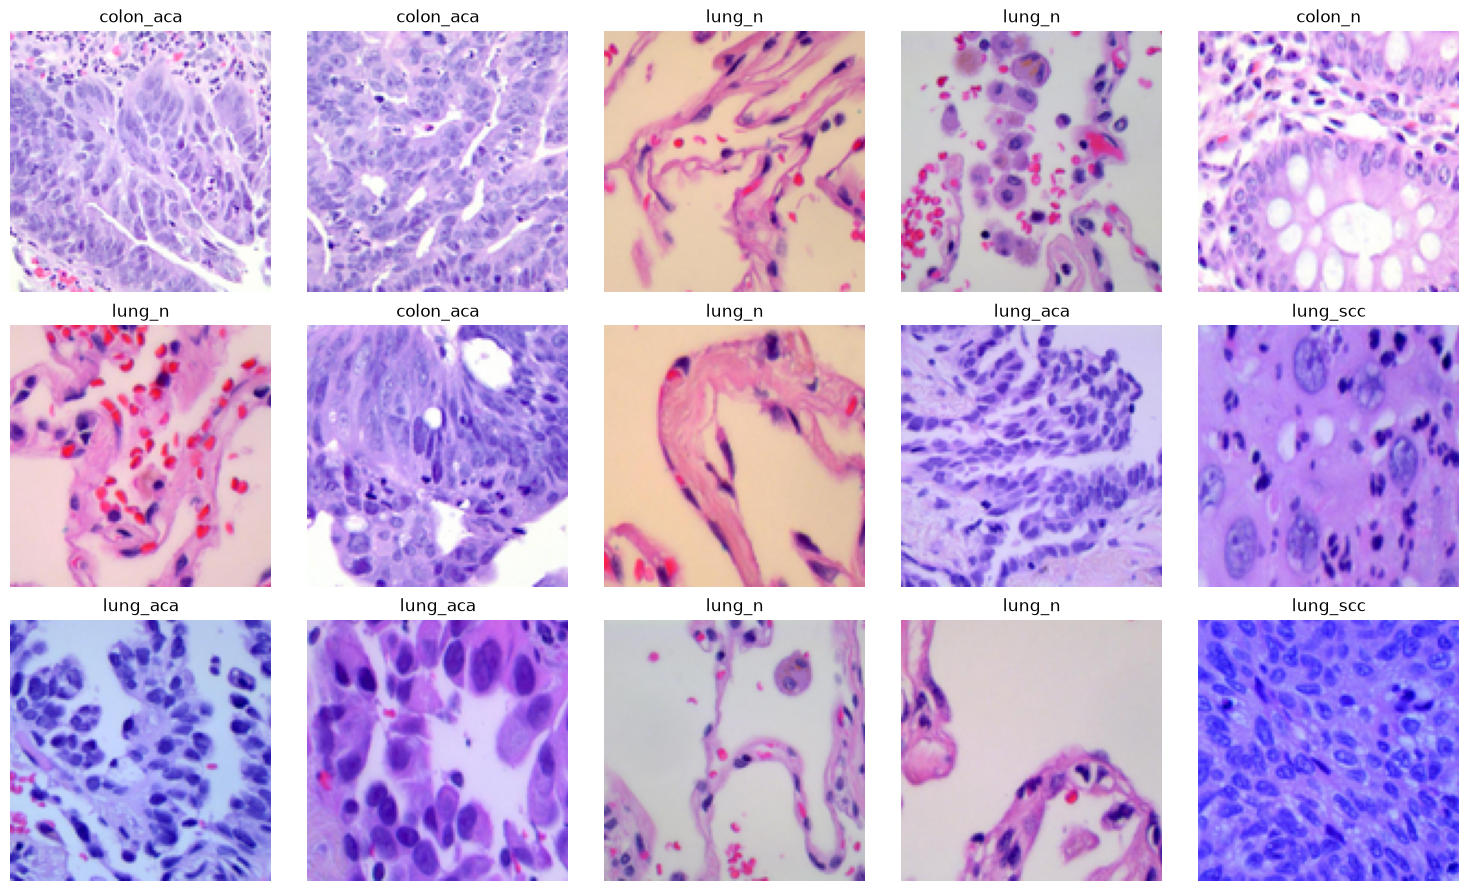

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Randomly select 15 images without replacement
rng = np.random.default_rng(42)
indices = rng.choice(len(data), size=15, replace=False)

plt.figure(figsize=(15, 9))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(data[indices[i]])
    plt.title(class_labels[indices[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualize Class Label Distribution

Create a bar plot showing how many samples the dataset has for each class.

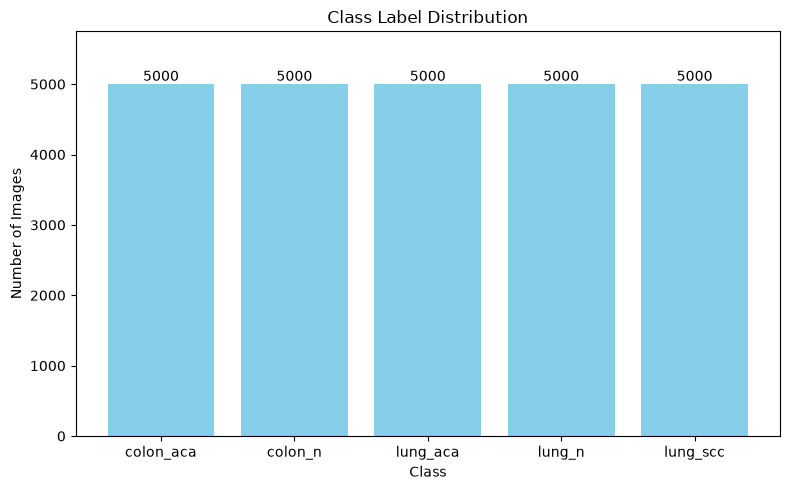

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Count the number of images in each class
classes, counts = np.unique(class_labels, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color="skyblue")
plt.title("Class Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.ylim(0, counts.max() * 1.15)

# Display the count above each bar
for i in range(len(classes)):
    plt.text(i, counts[i], str(counts[i]), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Baseline Model

Implement the baseline CNN exactly as described in the assignment, train it for 15 epochs
with a batch size of 32, and analyse its performance (accuracy/loss curves, ROC curve with
AUC, confusion matrix, and performance measures for the validation and test sets).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, models, regularizers
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

keras.utils.set_random_seed(42)
class_names = np.asarray(encoder.categories_[0])
num_classes = len(class_names)


In [9]:
def build_baseline():
    # Match the architecture in Figure 2 without extra preprocessing layers.
    model = models.Sequential([
        layers.Input(shape=(120, 120, 3)),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


In [10]:

baseline_model = build_baseline()
baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,309 (3.73 MB)

 Trainable params: 978,309 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train for exactly 15 epochs with the required batch size of 32.
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=32, shuffle=True, verbose=1
)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 163ms/step - accuracy: 0.7075 - loss: 1.3130 - val_accuracy: 0.7976 - val_loss: 0.4575
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - accuracy: 0.8615 - loss: 0.3446 - val_accuracy: 0.8992 - val_loss: 0.2683
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 147ms/step - accuracy: 0.8991 - loss: 0.2565 - val_accuracy: 0.9110 - val_loss: 0.3221
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9215 - loss: 0.2094 - val_accuracy: 0.9218 - val_loss: 0.2229
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - accuracy: 0.9319 - loss: 0.1846 - val_accuracy: 0.9354 - val_loss: 0.1893
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 247ms/step - accuracy: 0.9455 - loss: 0.1402 - val_accuracy: 0.9066 - val_loss: 0.2727
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - accuracy: 0.9471 - loss: 0.1424 - val_accuracy: 0.9154 - val_loss: 0.2805
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 297ms/step - accuracy: 0.9506 - loss:

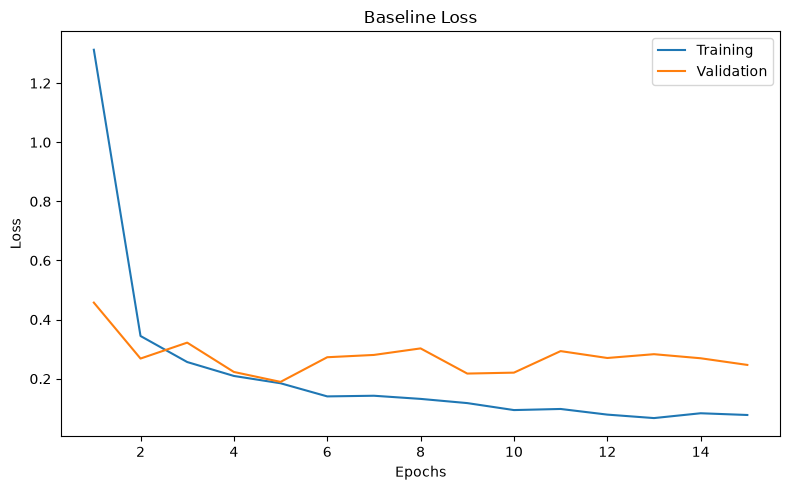

In [12]:
# Plot baseline training and validation loss.
train_loss = baseline_history.history['loss']
val_loss = baseline_history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training')
plt.plot(epochs, val_loss, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline Loss')
plt.legend()
plt.tight_layout()
plt.show()


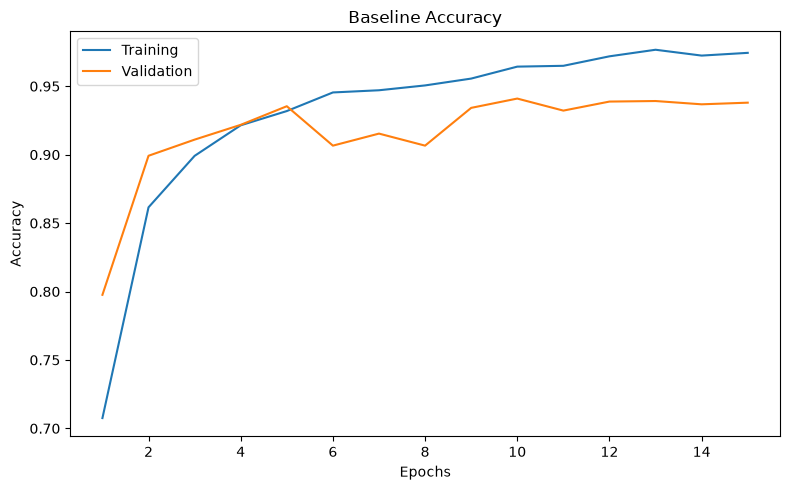

In [13]:
# Plot baseline training and validation accuracy.
train_accuracy = baseline_history.history['accuracy']
val_accuracy = baseline_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, label='Training')
plt.plot(epochs, val_accuracy, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Predict validation probabilities once for all evaluation cells below.
baseline_val_probabilities = baseline_model.predict(X_val, batch_size=32, verbose=0)
baseline_val_pred = baseline_val_probabilities.argmax(axis=1)
baseline_val_true = y_val.argmax(axis=1)


In [15]:
# Display validation accuracy, precision, recall and F1-score.
print('Baseline - Validation')
print(classification_report(
    baseline_val_true, baseline_val_pred,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))


Baseline - Validation
              precision    recall  f1-score   support

   colon_aca     0.9387    0.9800    0.9589      1000
     colon_n     0.9864    0.9450    0.9653      1000
    lung_aca     0.9215    0.8340    0.8756      1000
      lung_n     0.9930    0.9870    0.9900      1000
    lung_scc     0.8590    0.9440    0.8995      1000

    accuracy                         0.9380      5000
   macro avg     0.9397    0.9380    0.9378      5000
weighted avg     0.9397    0.9380    0.9378      5000



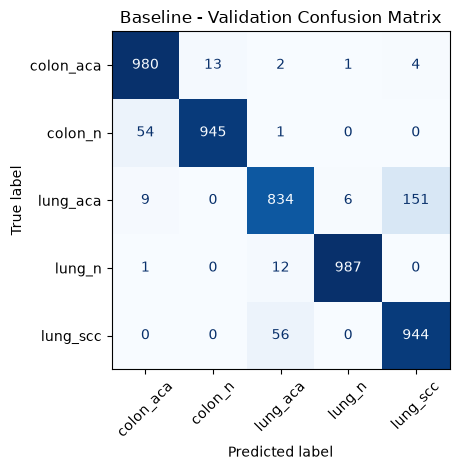

In [16]:
# Plot the validation confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    baseline_val_true, baseline_val_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('Baseline - Validation Confusion Matrix')
plt.tight_layout()
plt.show()


In [17]:
# Calculate one-vs-rest AUC for each class and the macro average.
baseline_val_auc = roc_auc_score(
    y_val, baseline_val_probabilities, average=None
)
for i in range(num_classes):
    print(f'{class_names[i]} AUC: {baseline_val_auc[i]:.4f}')
print(f'Macro AUC: {baseline_val_auc.mean():.4f}')


colon_aca AUC: 0.9982
colon_n AUC: 0.9993
lung_aca AUC: 0.9849
lung_n AUC: 0.9985
lung_scc AUC: 0.9904
Macro AUC: 0.9943


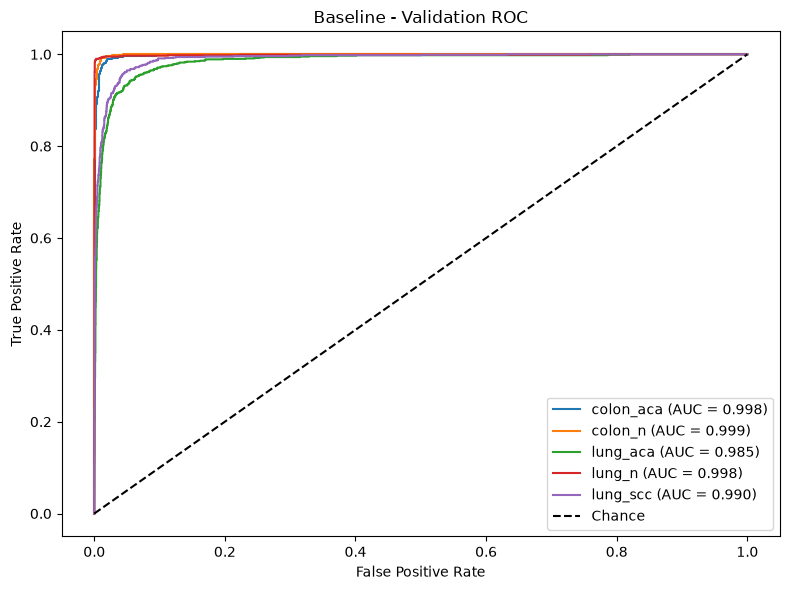

In [18]:
# Plot one-vs-rest ROC curves using probabilities, not predicted labels.
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val[:, i], baseline_val_probabilities[:, i])
    plt.plot(fpr, tpr,
             label=f'{class_names[i]} (AUC = {baseline_val_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline - Validation ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [19]:
# Run test evaluation only after finalizing model choices on the validation set.
# Predict test probabilities once for all evaluation cells below.
baseline_test_probabilities = baseline_model.predict(X_test, batch_size=32, verbose=0)
baseline_test_pred = baseline_test_probabilities.argmax(axis=1)
baseline_test_true = y_test.argmax(axis=1)


In [20]:
# Display test accuracy, precision, recall and F1-score.
print('Baseline - Test')
print(classification_report(
    baseline_test_true, baseline_test_pred,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))


Baseline - Test
              precision    recall  f1-score   support

   colon_aca     0.9216    0.9760    0.9480      1000
     colon_n     0.9883    0.9310    0.9588      1000
    lung_aca     0.9237    0.8600    0.8907      1000
      lung_n     0.9880    0.9860    0.9870      1000
    lung_scc     0.8832    0.9450    0.9130      1000

    accuracy                         0.9396      5000
   macro avg     0.9410    0.9396    0.9395      5000
weighted avg     0.9410    0.9396    0.9395      5000



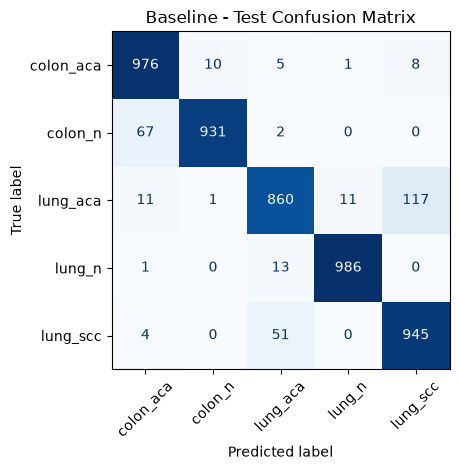

In [21]:
# Plot the test confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    baseline_test_true, baseline_test_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('Baseline - Test Confusion Matrix')
plt.tight_layout()
plt.show()


In [22]:
# Calculate one-vs-rest AUC for each class and the macro average.
baseline_test_auc = roc_auc_score(
    y_test, baseline_test_probabilities, average=None
)
for i in range(num_classes):
    print(f'{class_names[i]} AUC: {baseline_test_auc[i]:.4f}')
print(f'Macro AUC: {baseline_test_auc.mean():.4f}')


colon_aca AUC: 0.9967
colon_n AUC: 0.9990
lung_aca AUC: 0.9838
lung_n AUC: 0.9991
lung_scc AUC: 0.9913
Macro AUC: 0.9940


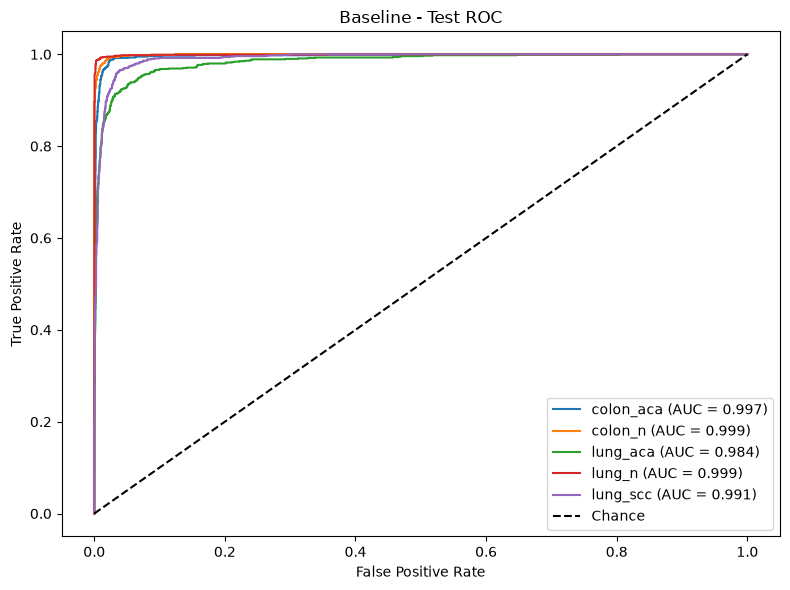

In [23]:
# Plot one-vs-rest ROC curves using probabilities, not predicted labels.
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], baseline_test_probabilities[:, i])
    plt.plot(fpr, tpr,
             label=f'{class_names[i]} (AUC = {baseline_test_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline - Test ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Enhanced Model

Adapt the baseline by intentionally tweaking at least six different hyperparameters, and
compare the results against the baseline.

In [24]:
# Build experimental models without changing the original baseline.
def build_adjusted_model(dense_units=64, kernel_size=(3, 3)):
    model = models.Sequential([
        layers.Input(shape=(120, 120, 3)),
        layers.Conv2D(32, kernel_size, padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, kernel_size, padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, kernel_size, padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    # Keep the training settings identical to the baseline.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


In [25]:
# Change only dense units from 64 to 128; keep all kernels at 3x3.
# Start with fresh weights and use the same seed for each experiment.
keras.utils.set_random_seed(42)
dense128_model = build_adjusted_model(dense_units=128)
dense128_model.summary()

dense128_history = dense128_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=32, shuffle=True, verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,843,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,293 (7.25 MB)

 Trainable params: 1,900,293 (7.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 244ms/step - accuracy: 0.7655 - loss: 1.4624 - val_accuracy: 0.8728 - val_loss: 0.3206
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 229ms/step - accuracy: 0.8703 - loss: 0.3303 - val_accuracy: 0.8718 - val_loss: 0.3175
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 330ms/step - accuracy: 0.9023 - loss: 0.2545 - val_accuracy: 0.8956 - val_loss: 0.2746
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 277ms/step - accuracy: 0.9185 - loss: 0.2119 - val_accuracy: 0.8604 - val_loss: 0.4194
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - accuracy: 0.9377 - loss: 0.1736 - val_accuracy: 0.9164 - val_loss: 0.2539
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - accuracy: 0.9432 - loss: 0.1557 - val_accuracy: 0.8146 - val_loss: 0.5802
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - accuracy: 0.9341 - loss: 0.1754 - val_accuracy: 0.8536 - val_loss: 0.4930
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - accuracy: 0.9546 -

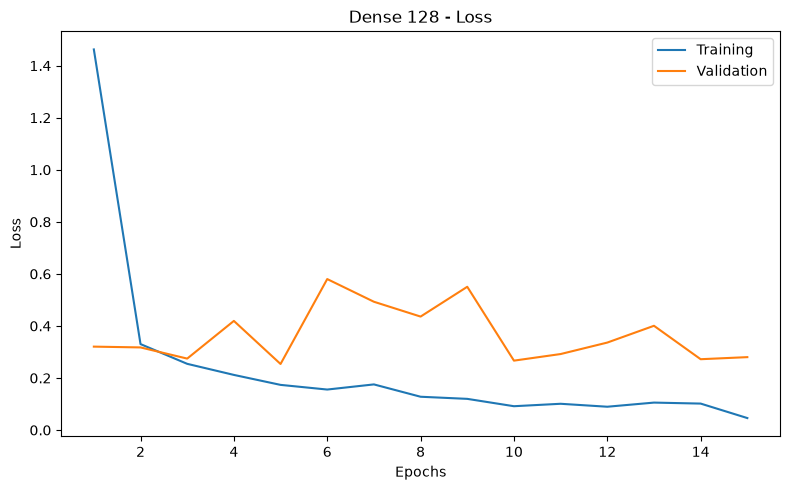

In [26]:
# Plot training and validation loss for the Dense 128 experiment.
plt.figure(figsize=(8, 5))
epochs = range(1, len(dense128_history.history['loss']) + 1)
plt.plot(epochs, dense128_history.history['loss'], label='Training')
plt.plot(epochs, dense128_history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Dense 128 - Loss')
plt.legend()
plt.tight_layout()
plt.show()


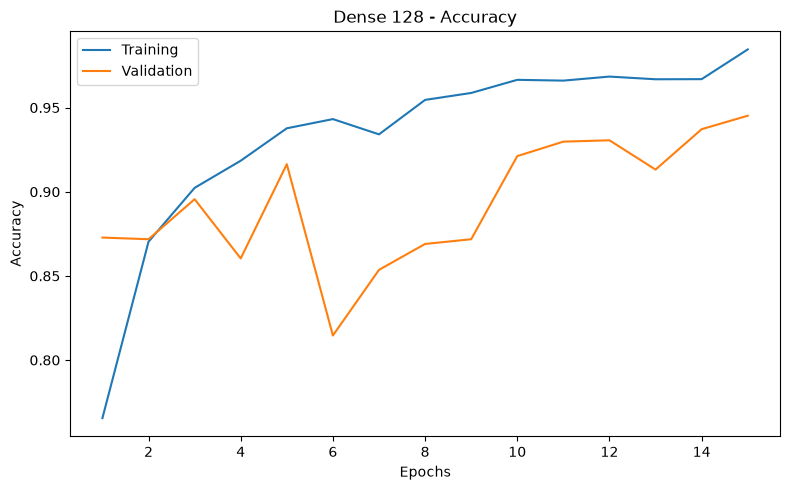

In [27]:
# Plot training and validation accuracy for the Dense 128 experiment.
plt.figure(figsize=(8, 5))
epochs = range(1, len(dense128_history.history['accuracy']) + 1)
plt.plot(epochs, dense128_history.history['accuracy'], label='Training')
plt.plot(epochs, dense128_history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Dense 128 - Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Use validation predictions to assess the experiment without tuning on test data.
dense128_val_probabilities = dense128_model.predict(X_val, batch_size=32, verbose=0)
dense128_val_pred = dense128_val_probabilities.argmax(axis=1)
dense128_val_true = y_val.argmax(axis=1)
print('Dense 128 - Validation')
print(classification_report(
    dense128_val_true, dense128_val_pred,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))


Dense 128 - Validation
              precision    recall  f1-score   support

   colon_aca     0.9461    0.9660    0.9560      1000
     colon_n     0.9696    0.9560    0.9627      1000
    lung_aca     0.8980    0.9070    0.9025      1000
      lung_n     0.9920    0.9880    0.9900      1000
    lung_scc     0.9210    0.9090    0.9149      1000

    accuracy                         0.9452      5000
   macro avg     0.9453    0.9452    0.9452      5000
weighted avg     0.9453    0.9452    0.9452      5000



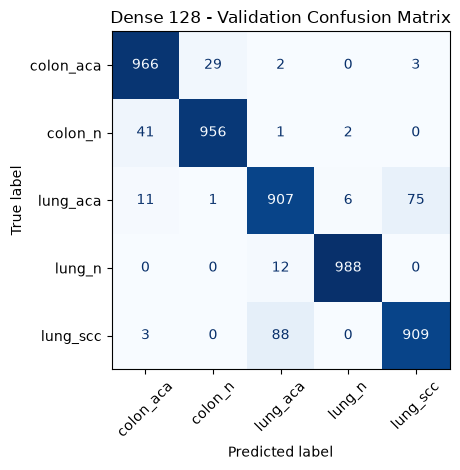

In [29]:
# Plot the validation confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    dense128_val_true, dense128_val_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('Dense 128 - Validation Confusion Matrix')
plt.tight_layout()
plt.show()


In [30]:
# Calculate validation AUC for each class and the macro average.
dense128_val_auc = roc_auc_score(y_val, dense128_val_probabilities, average=None)
for i in range(num_classes):
    print(f'{class_names[i]} AUC: {dense128_val_auc[i]:.4f}')
print(f'Macro AUC: {dense128_val_auc.mean():.4f}')


colon_aca AUC: 0.9974
colon_n AUC: 0.9984
lung_aca AUC: 0.9859
lung_n AUC: 0.9989
lung_scc AUC: 0.9914
Macro AUC: 0.9944


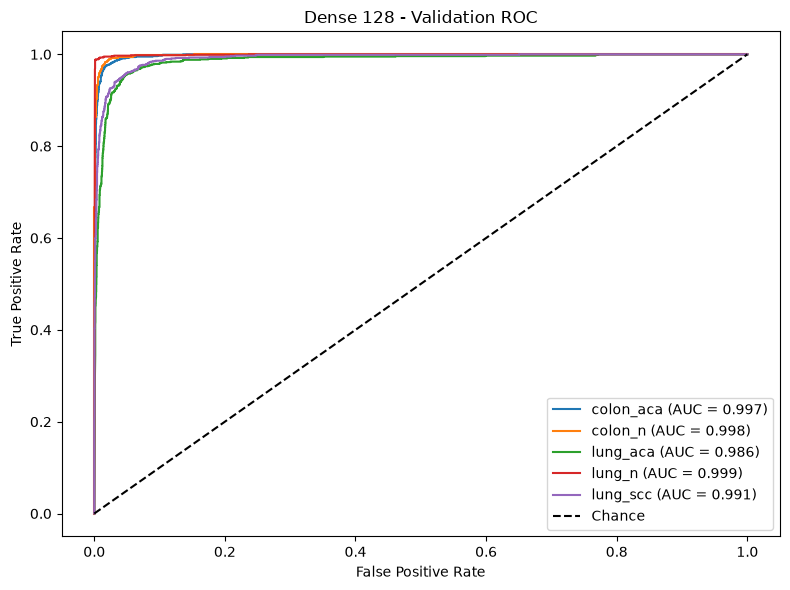

In [31]:
# Plot validation ROC curves using class probabilities.
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val[:, i], dense128_val_probabilities[:, i])
    plt.plot(fpr, tpr,
             label=f'{class_names[i]} (AUC = {dense128_val_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Dense 128 - Validation ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [32]:
# Change only kernel size from 3x3 to 5x5; keep dense units at 64.
# Start with fresh weights and use the same seed for each experiment.
keras.utils.set_random_seed(42)
kernel5_model = build_adjusted_model(kernel_size=(5, 5))
kernel5_model.summary()

kernel5_history = kernel5_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=32, shuffle=True, verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 120, 120, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,149 (4.11 MB)

 Trainable params: 1,078,149 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 275s 586ms/step - accuracy: 0.6449 - loss: 2.5755 - val_accuracy: 0.7624 - val_loss: 0.5011
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 319s 680ms/step - accuracy: 0.8241 - loss: 0.4134 - val_accuracy: 0.8744 - val_loss: 0.3049
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 241s 513ms/step - accuracy: 0.8775 - loss: 0.3040 - val_accuracy: 0.8578 - val_loss: 0.4000
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 340s 726ms/step - accuracy: 0.9057 - loss: 0.2444 - val_accuracy: 0.8872 - val_loss: 0.3303
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 412s 878ms/step - accuracy: 0.9196 - loss: 0.2117 - val_accuracy: 0.9160 - val_loss: 0.2550
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 341s 728ms/step - accuracy: 0.9353 - loss: 0.1709 - val_accuracy: 0.9182 - val_loss: 0.2892
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 300s 638ms/step - accuracy: 0.9393 - loss: 0.1595 - val_accuracy: 0.9312 - val_loss: 0.2618
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 300s 640ms/step - accuracy: 0.9376 -

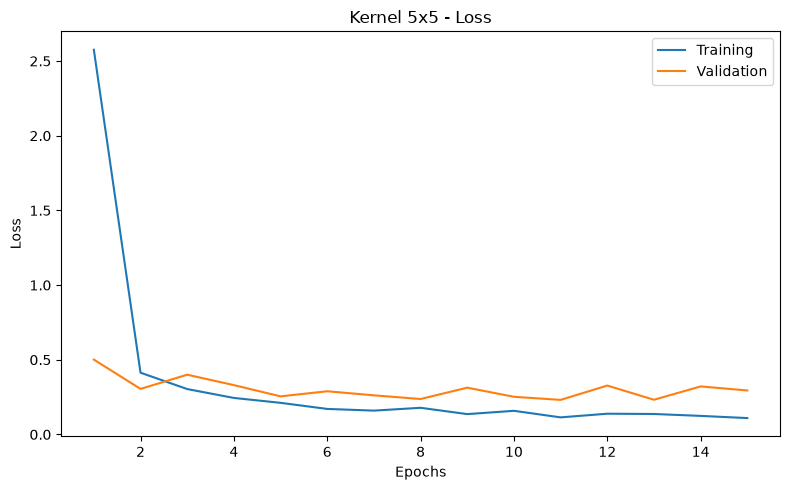

In [33]:
# Plot training and validation loss for the Kernel 5x5 experiment.
plt.figure(figsize=(8, 5))
epochs = range(1, len(kernel5_history.history['loss']) + 1)
plt.plot(epochs, kernel5_history.history['loss'], label='Training')
plt.plot(epochs, kernel5_history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Kernel 5x5 - Loss')
plt.legend()
plt.tight_layout()
plt.show()


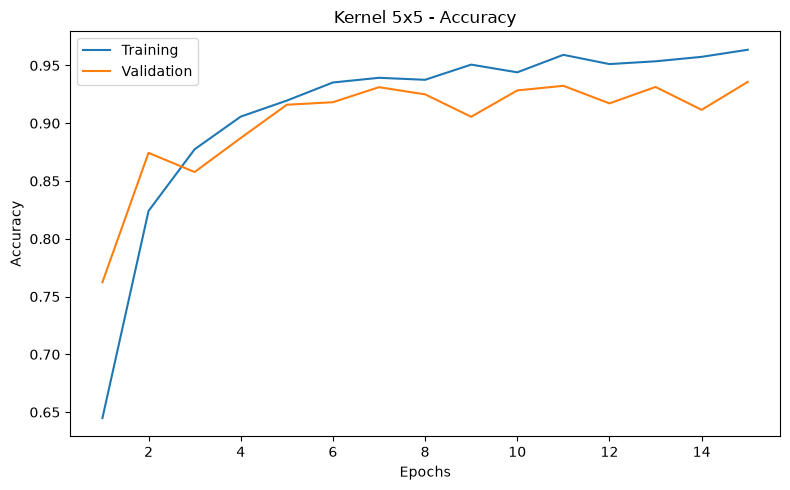

In [34]:
# Plot training and validation accuracy for the Kernel 5x5 experiment.
plt.figure(figsize=(8, 5))
epochs = range(1, len(kernel5_history.history['accuracy']) + 1)
plt.plot(epochs, kernel5_history.history['accuracy'], label='Training')
plt.plot(epochs, kernel5_history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Kernel 5x5 - Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
# Use validation predictions to assess the experiment without tuning on test data.
kernel5_val_probabilities = kernel5_model.predict(X_val, batch_size=32, verbose=0)
kernel5_val_pred = kernel5_val_probabilities.argmax(axis=1)
kernel5_val_true = y_val.argmax(axis=1)
print('Kernel 5x5 - Validation')
print(classification_report(
    kernel5_val_true, kernel5_val_pred,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))


Kernel 5x5 - Validation
              precision    recall  f1-score   support

   colon_aca     0.9509    0.9690    0.9599      1000
     colon_n     0.9746    0.9610    0.9678      1000
    lung_aca     0.8863    0.8650    0.8755      1000
      lung_n     0.9660    0.9940    0.9798      1000
    lung_scc     0.8990    0.8900    0.8945      1000

    accuracy                         0.9358      5000
   macro avg     0.9354    0.9358    0.9355      5000
weighted avg     0.9354    0.9358    0.9355      5000



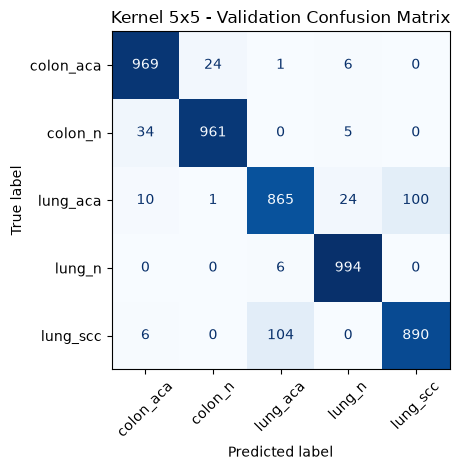

In [36]:
# Plot the validation confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    kernel5_val_true, kernel5_val_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('Kernel 5x5 - Validation Confusion Matrix')
plt.tight_layout()
plt.show()


In [37]:
# Calculate validation AUC for each class and the macro average.
kernel5_val_auc = roc_auc_score(y_val, kernel5_val_probabilities, average=None)
for i in range(num_classes):
    print(f'{class_names[i]} AUC: {kernel5_val_auc[i]:.4f}')
print(f'Macro AUC: {kernel5_val_auc.mean():.4f}')


colon_aca AUC: 0.9985
colon_n AUC: 0.9984
lung_aca AUC: 0.9815
lung_n AUC: 0.9987
lung_scc AUC: 0.9911
Macro AUC: 0.9936


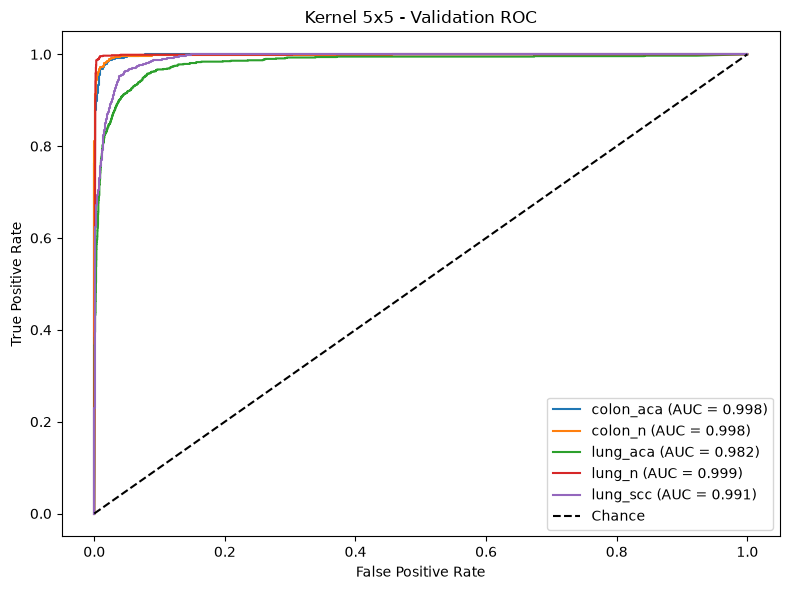

In [38]:
# Plot validation ROC curves using class probabilities.
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val[:, i], kernel5_val_probabilities[:, i])
    plt.plot(fpr, tpr,
             label=f'{class_names[i]} (AUC = {kernel5_val_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kernel 5x5 - Validation ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [39]:
# Compare validation results from the final epoch of each 15-epoch run.
import pandas as pd

experiment_results = []
for name, history in [
    ('Baseline', baseline_history),
    ('Dense 128', dense128_history),
    ('Kernel 5x5', kernel5_history)
]:
    experiment_results.append({
        'Experiment': name,
        'Train accuracy': history.history['accuracy'][-1],
        'Validation accuracy': history.history['val_accuracy'][-1],
        'Validation loss': history.history['val_loss'][-1]
    })

experiment_results = pd.DataFrame(experiment_results)
print(experiment_results.round(4).to_string(index=False))


Experiment  Train accuracy  Validation accuracy  Validation loss
  Baseline          0.9744               0.9380           0.2467
 Dense 128          0.9846               0.9452           0.2802
Kernel 5x5          0.9636               0.9358           0.2945
